In [1]:
import pandas as pd
import torch 
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# Set random seeds for reproducibility 
torch.manual_seed(42)

In [4]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


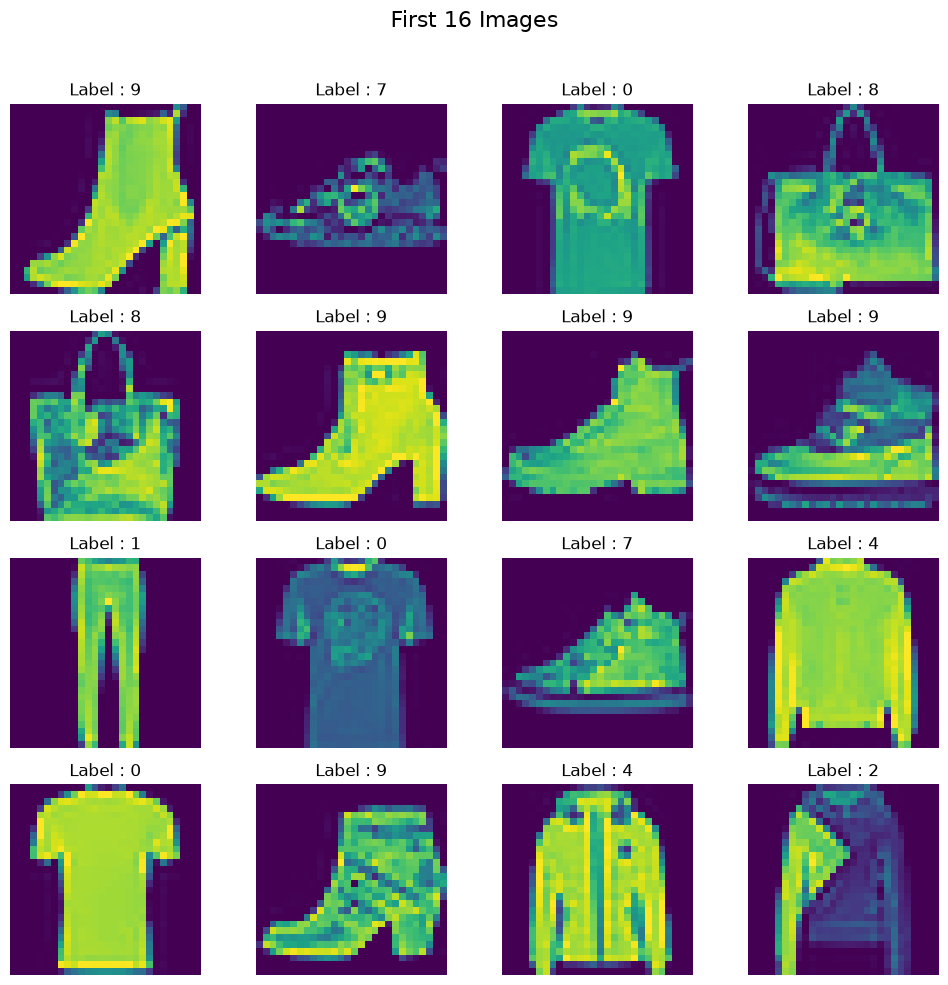

In [9]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize = (10, 10))
fig.suptitle("First 16 Images", fontsize = 16)


# Plot the first 16 images from the dataset 
for i , ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28) # Reshape to 28x 28
    ax.imshow(img) # Display in grayscale
    ax.axis("off") # Remove axis for a clearner look 
    ax.set_title(f"Label : {df.iloc[i, 0]}") # Show the label

plt.tight_layout(rect = [0, 0, 1, 0.96]) # Adjust layout to fit the fitle
plt.show()

In [10]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [12]:
# Scalling the features
X_train = X_train/255.0
X_test = X_test/255.0

In [15]:
# Create CustomDataset Class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.featues = torch.tensor(features, dtype = torch.float32)
        self.labels = torch.tensor(labels, dtype = torch.long)

    def __len__(self):
        return len(self.featues)

    def __getitem__(self, index):
        return self.featues[index], self.labels[index]

In [16]:
# Create train_dataset object 
train_dataset = CustomDataset(X_train, y_train)

In [17]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [18]:
# Create test_dataset object 
test_dataset = CustomDataset(X_test, y_test)

In [19]:
# Create train and test loader 
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
test_loader = DataLoader(test_dataset, batch_size= 32, shuffle= False)

In [26]:
# Define NN Class 

class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [27]:
# Important parametes 
epochs = 100
learning_rate = 0.1

In [28]:
# Instantiate the model 
model = MyNN(X_train.shape[1])

#Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer 
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

In [30]:
len(train_loader)

150

In [31]:
# Training Loop 
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features , batch_labels in train_loader:
        # forward pass 
        outputs = model(batch_features)


        # calculate looss 
        loss = criterion (outputs, batch_labels)


        # backprop
        optimizer.zero_grad()
        loss.backward() 


        # update gradient
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()
    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch : {epoch + 1}, loss : {avg_loss}")

Epoch : 1, loss : 0.18445233751592846
Epoch : 2, loss : 0.1028635243885219
Epoch : 3, loss : 0.0676962872222066
Epoch : 4, loss : 0.05161697323123614
Epoch : 5, loss : 0.04936244743565718
Epoch : 6, loss : 0.0723623055157562
Epoch : 7, loss : 0.015402822552326445
Epoch : 8, loss : 0.008557964497401068
Epoch : 9, loss : 0.007306675770475219
Epoch : 10, loss : 0.006061061628958366
Epoch : 11, loss : 0.004638720661750995
Epoch : 12, loss : 0.003711260152243388
Epoch : 13, loss : 0.0035054568897855158
Epoch : 14, loss : 0.004417610205709934
Epoch : 15, loss : 0.002702501691140545
Epoch : 16, loss : 0.002349713105359115
Epoch : 17, loss : 0.0021418761066161096
Epoch : 18, loss : 0.0020886022554865726
Epoch : 19, loss : 0.0020553552971493143
Epoch : 20, loss : 0.001924288550314183
Epoch : 21, loss : 0.0018263713089982049
Epoch : 22, loss : 0.001649603807212164
Epoch : 23, loss : 0.0018960576311413508
Epoch : 24, loss : 0.0021306659595575184
Epoch : 25, loss : 0.0014074677174600462
Epoch : 26

In [32]:
# Set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
# Evaluation code 
total = 0
correct = 0 
with torch.no_grad():
    for batch_features , batch_labels in test_loader:
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

    print("Accuracy : ", correct/total)

0.8433333333333334
